In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, f1_score , recall_score, confusion_matrix ,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("/content/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561.0,No,1.0
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504.0,Yes,0.0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635.0,No,1.0
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675.0,No,1.0
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586.0,No,1.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13192 entries, 0 to 13191
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      13192 non-null  float64
 1   person_gender                   13192 non-null  object 
 2   person_education                13192 non-null  object 
 3   person_income                   13192 non-null  float64
 4   person_emp_exp                  13192 non-null  int64  
 5   person_home_ownership           13192 non-null  object 
 6   loan_amnt                       13192 non-null  float64
 7   loan_intent                     13192 non-null  object 
 8   loan_int_rate                   13191 non-null  float64
 9   loan_percent_income             13191 non-null  float64
 10  cb_person_cred_hist_length      13191 non-null  float64
 11  credit_score                    13191 non-null  float64
 12  previous_loan_defaults_on_file  

In [4]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,13192.000000,13192.000000,13192.000000,13192.000000,13191.000000,13191.000000,13191.000000,13191.000000,13191.000000
mean,23.598620,65540.724378,1.663811,8683.781837,10.937914,0.144580,2.996058,626.280570,0.232583
std,2.441425,33016.662566,2.653862,5709.347333,3.048846,0.087066,0.818466,49.523674,0.422494
min,20.000000,12231.000000,0.000000,500.000000,5.420000,0.000000,2.000000,421.000000,0.000000
25%,22.000000,43963.750000,0.000000,4800.000000,8.000000,0.080000,2.000000,595.000000,0.000000
50%,23.000000,60996.500000,1.000000,7200.000000,11.010000,0.130000,3.000000,634.000000,0.000000
75%,25.000000,79976.250000,3.000000,11000.000000,13.060000,0.190000,4.000000,663.000000,0.000000
max,144.000000,600891.000000,125.000000,35000.000000,20.000000,0.660000,4.000000,807.000000,1.000000


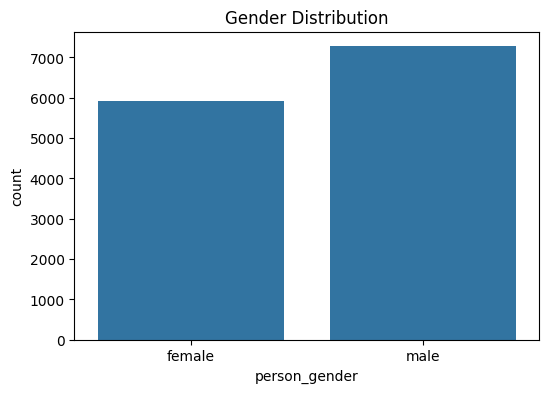

In [5]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="person_gender")

plt.title("Gender Distribution")
plt.show()

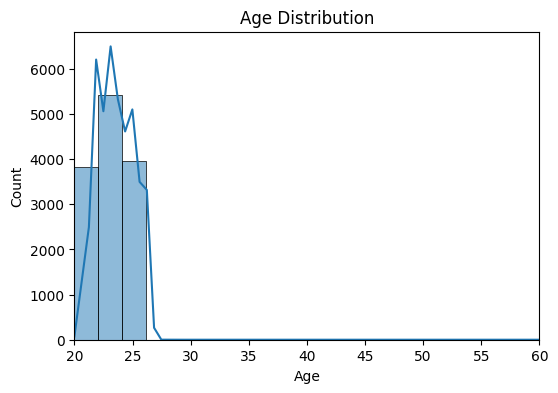

In [6]:
plt.figure(figsize=(6,4))

sns.histplot(df["person_age"], bins=60, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.xlim(20, 60)

plt.show()

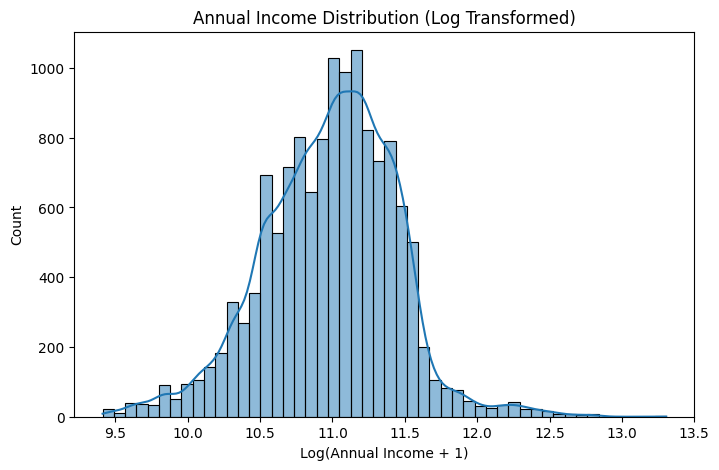

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["person_income"]), bins=50, kde=True)

plt.title("Annual Income Distribution (Log Transformed)")

plt.xlabel("Log(Annual Income + 1)")

plt.show()

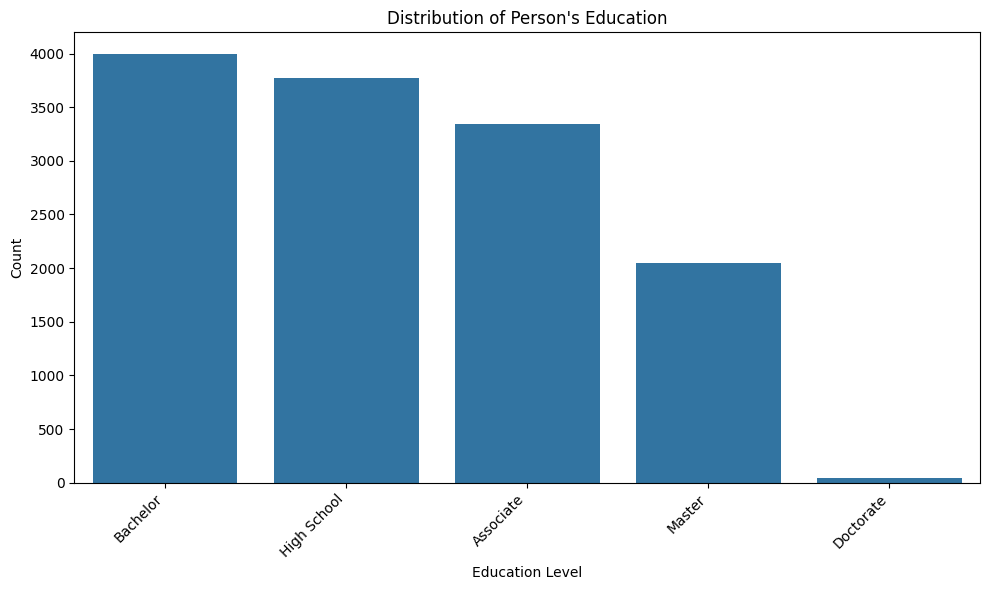

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="person_education", order=df["person_education"].value_counts().index)
plt.title("Distribution of Person's Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
import plotly.express as px

fig = px.box(df, y = "person_income", color = "person_gender",
             points = "all", notched = True,
             color_discrete_sequence = ["#0044FF", "#DE00FF"],
             title = "Male and Female Annual Income (k$)")

fig.update_traces(marker = dict(size = 5, symbol = "circle-open"))
fig.update_traces(fillcolor = "#000000")
fig.update_layout(template = "plotly_dark")

fig.show()

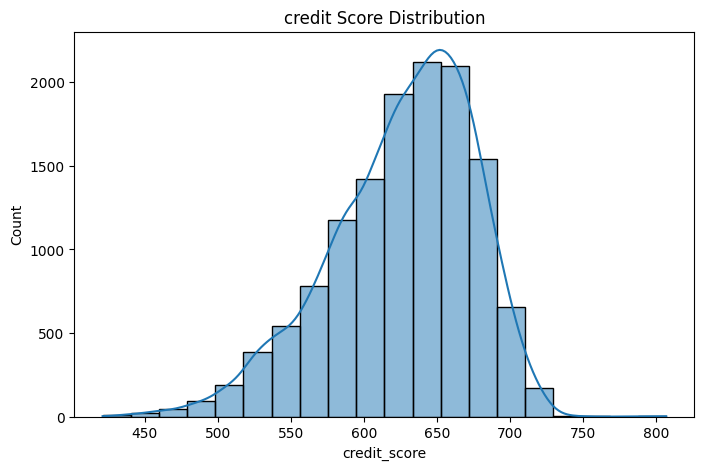

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df["credit_score"], bins=20, kde=True)

plt.title("credit Score Distribution")

plt.show()

In [11]:
# DATA PREPROCESSING
# 1. Missing Values Handling
missing_vals = df.isnull().sum()
if missing_vals.sum() > 0:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# 2. Feature and Target Separation
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 3. Categorical Encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/tmp/ipykernel_1633/766918461.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_1633/766918461.py:7: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

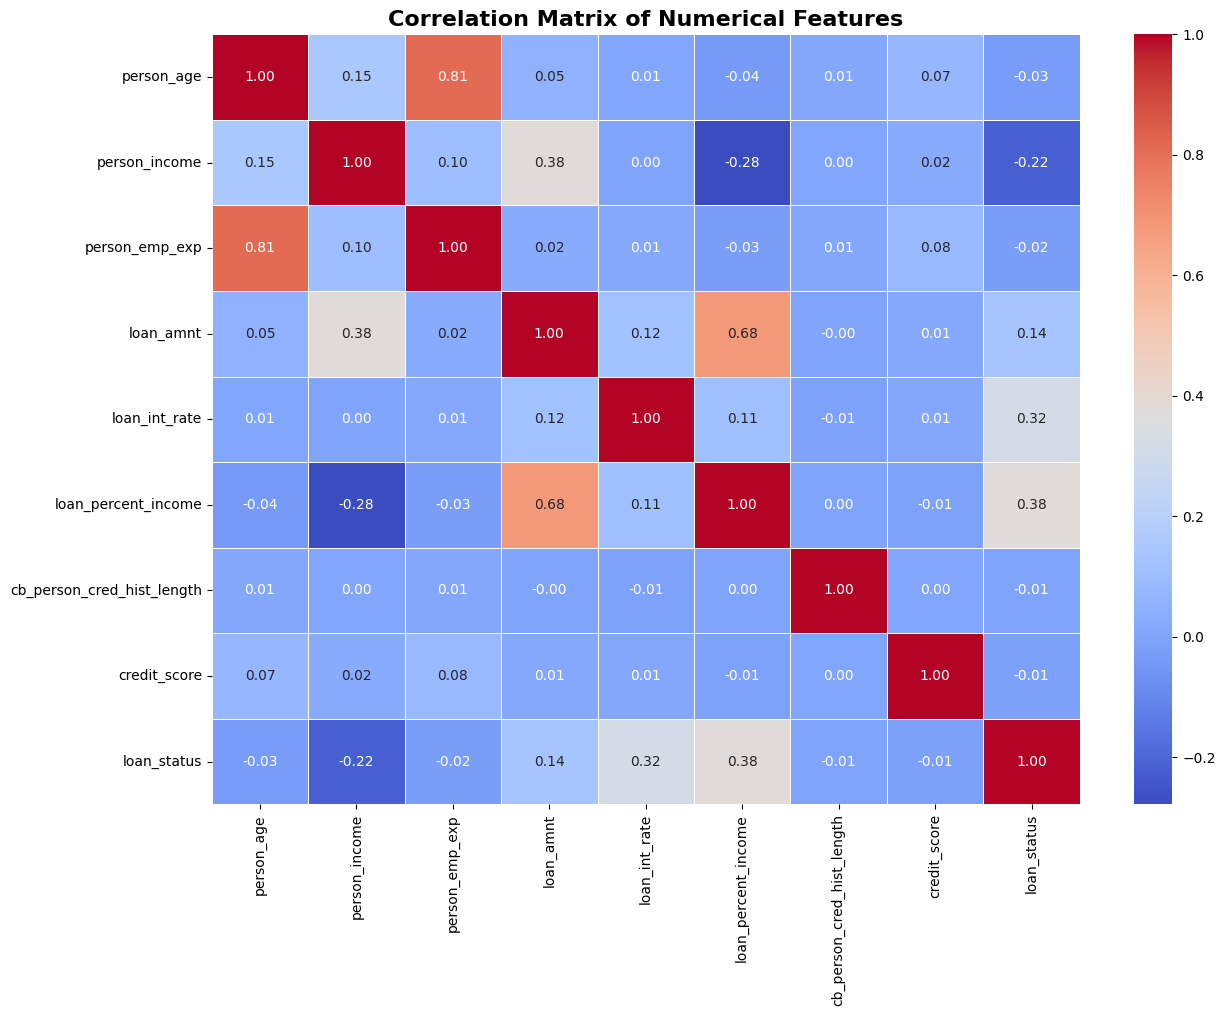

In [12]:
# Correlation Matrix
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

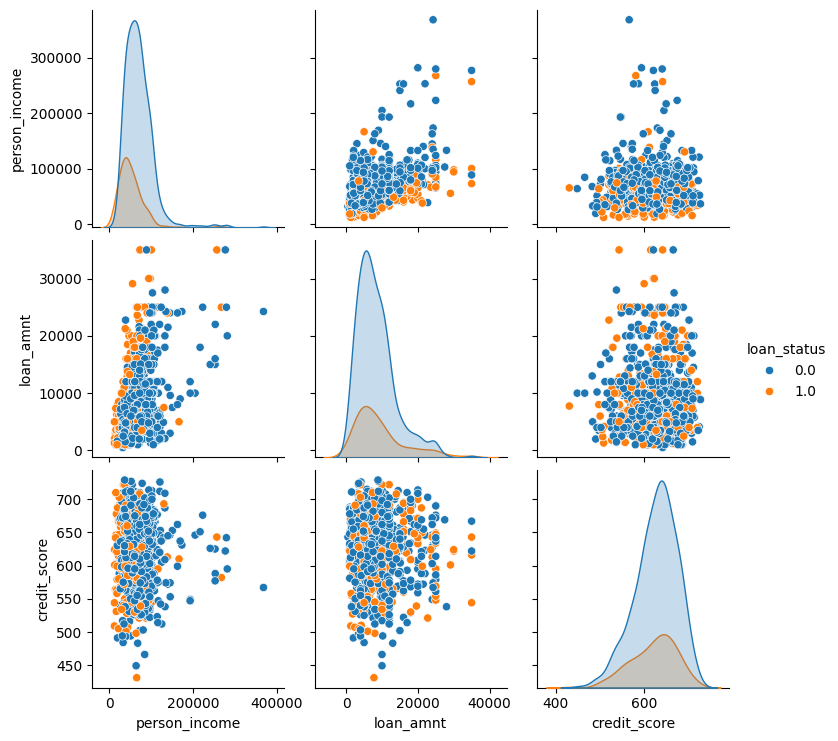

In [13]:
sns.pairplot(
    df.sample(1000, random_state=42),
    vars=[
        "person_income",
        "loan_amnt",
        "credit_score"
    ],
    hue="loan_status"
)

plt.show()

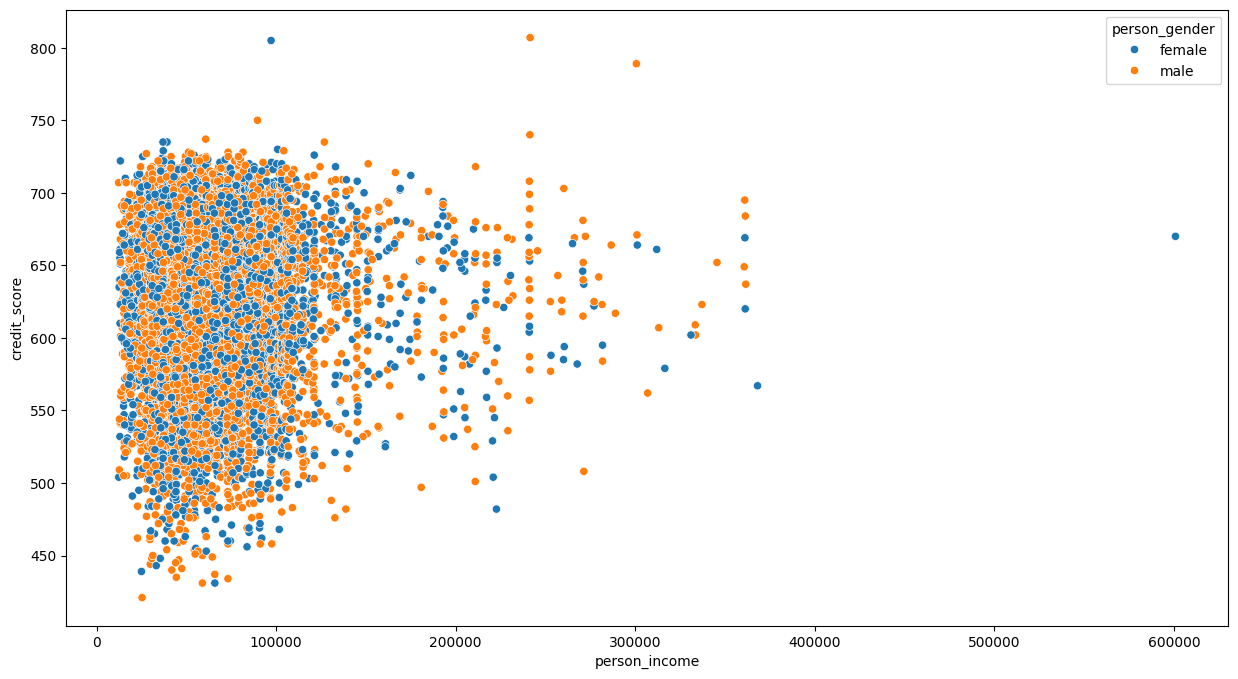

In [14]:
plt.figure(figsize=(15, 8))

sns.scatterplot(data=df, x='person_income', y='credit_score', hue='person_gender');

In [15]:
# Fit PCA
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

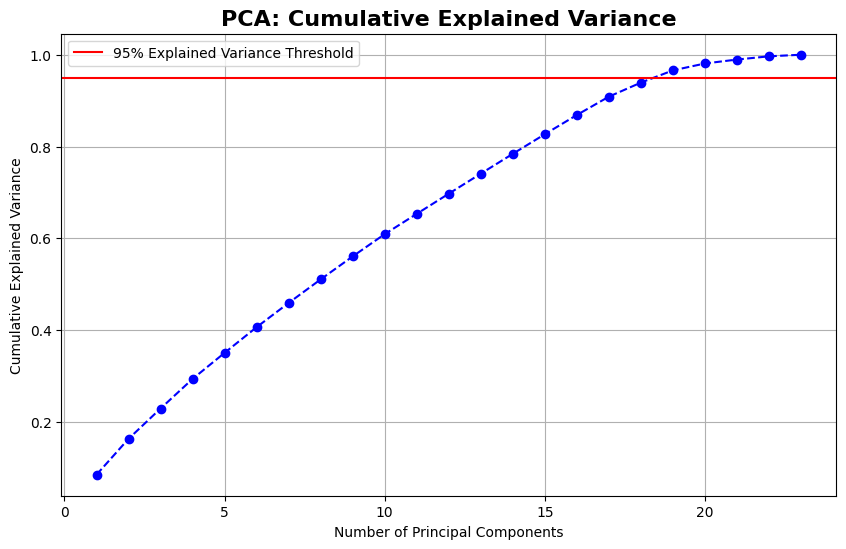

23 to 19 components.


In [16]:
# Explained Variance Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance Threshold')
plt.title('PCA: Cumulative Explained Variance', fontsize=16, fontweight='bold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Transform data retaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"{X_train_scaled.shape[1]} to {X_train_pca.shape[1]} components.")

Logistic Regression       
 [[1894  131]
 [ 131  483]] 
               precision    recall  f1-score   support

         0.0       0.94      0.94      0.94      2025
         1.0       0.79      0.79      0.79       614

    accuracy                           0.90      2639
   macro avg       0.86      0.86      0.86      2639
weighted avg       0.90      0.90      0.90      2639



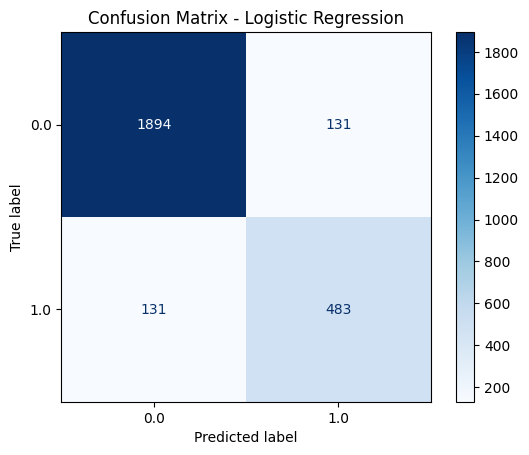

Logistic Regression       |ROC_AUC: 0.8610 
Random Forest             
 [[1971   54]
 [ 153  461]] 
               precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      2025
         1.0       0.90      0.75      0.82       614

    accuracy                           0.92      2639
   macro avg       0.91      0.86      0.88      2639
weighted avg       0.92      0.92      0.92      2639



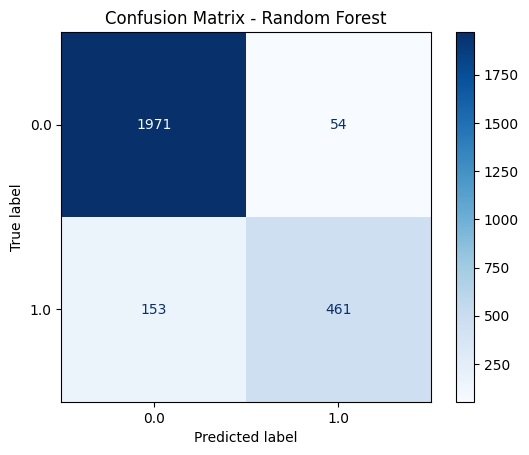

Random Forest             |ROC_AUC: 0.8621 


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[07:21:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




XGBoost                   
 [[1945   80]
 [ 130  484]] 
               precision    recall  f1-score   support

         0.0       0.94      0.96      0.95      2025
         1.0       0.86      0.79      0.82       614

    accuracy                           0.92      2639
   macro avg       0.90      0.87      0.89      2639
weighted avg       0.92      0.92      0.92      2639



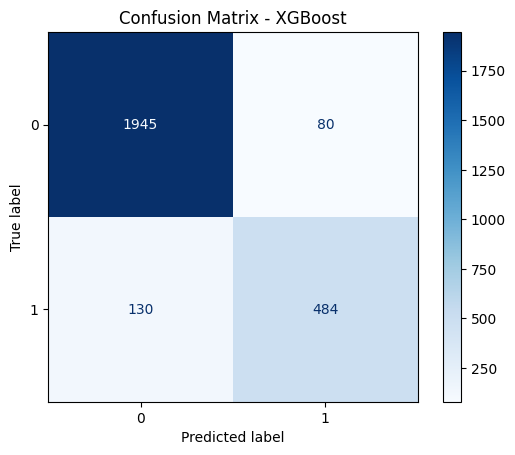

XGBoost                   |ROC_AUC: 0.8744 
Gradient Boosting         
 [[1964   61]
 [ 143  471]] 
               precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      2025
         1.0       0.89      0.77      0.82       614

    accuracy                           0.92      2639
   macro avg       0.91      0.87      0.89      2639
weighted avg       0.92      0.92      0.92      2639



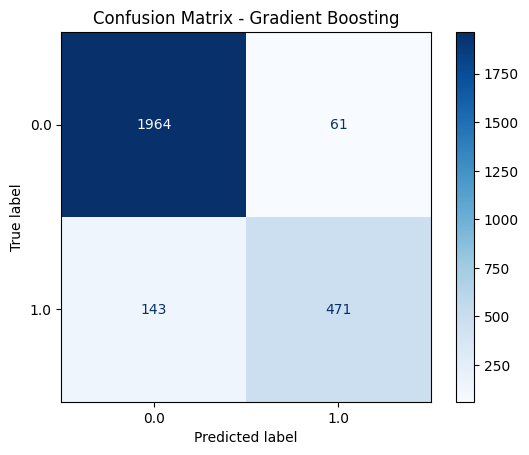

Gradient Boosting         |ROC_AUC: 0.8685 
K-Nearest Neighbors       
 [[1908  117]
 [ 193  421]] 
               precision    recall  f1-score   support

         0.0       0.91      0.94      0.92      2025
         1.0       0.78      0.69      0.73       614

    accuracy                           0.88      2639
   macro avg       0.85      0.81      0.83      2639
weighted avg       0.88      0.88      0.88      2639



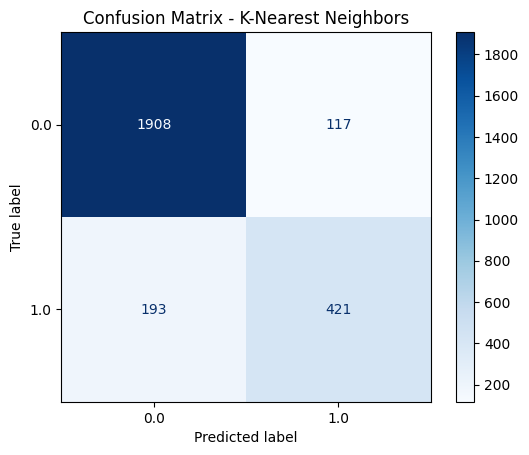

K-Nearest Neighbors       |ROC_AUC: 0.8139 
Decision Tree             
 [[1923  102]
 [ 195  419]] 
               precision    recall  f1-score   support

         0.0       0.91      0.95      0.93      2025
         1.0       0.80      0.68      0.74       614

    accuracy                           0.89      2639
   macro avg       0.86      0.82      0.83      2639
weighted avg       0.88      0.89      0.88      2639



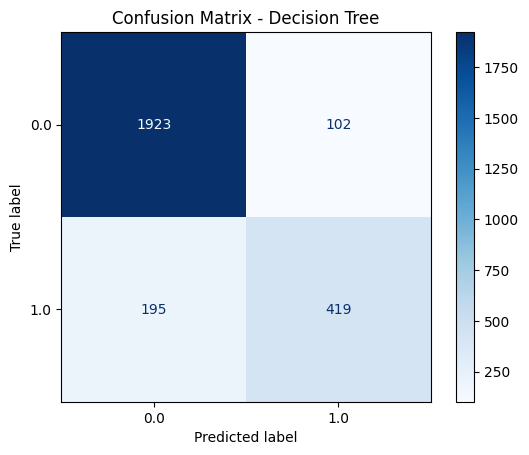

Decision Tree             |ROC_AUC: 0.8160 
Support Vector Machine    
 [[1937   88]
 [ 142  472]] 
               precision    recall  f1-score   support

         0.0       0.93      0.96      0.94      2025
         1.0       0.84      0.77      0.80       614

    accuracy                           0.91      2639
   macro avg       0.89      0.86      0.87      2639
weighted avg       0.91      0.91      0.91      2639



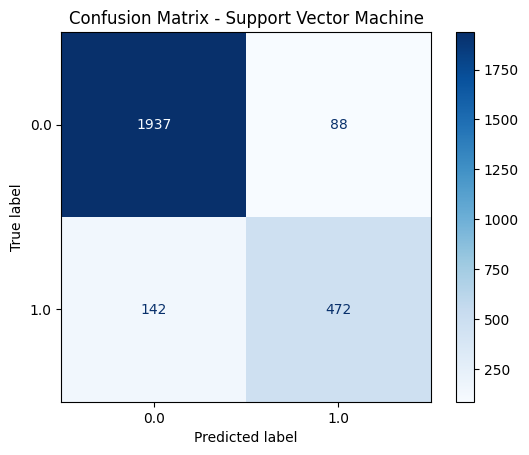

Support Vector Machine    |ROC_AUC: 0.8626 


In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results_no_pca = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train);
    y_pred = model.predict(X_test_scaled)

    roc = roc_auc_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    results_no_pca[name] = {'Accuracy': accuracy, 'ROC_AUC': roc}

    confusion = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)
    print(f"{name:25s}","\n",confusion_matrix(y_test, y_pred),"\n",classification_rep)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print(f"{name:25s} |ROC_AUC: {roc:.4f} ")

Logistic Regression       
 [[1886  139]
 [ 132  482]] 
               precision    recall  f1-score   support

         0.0       0.93      0.93      0.93      2025
         1.0       0.78      0.79      0.78       614

    accuracy                           0.90      2639
   macro avg       0.86      0.86      0.86      2639
weighted avg       0.90      0.90      0.90      2639



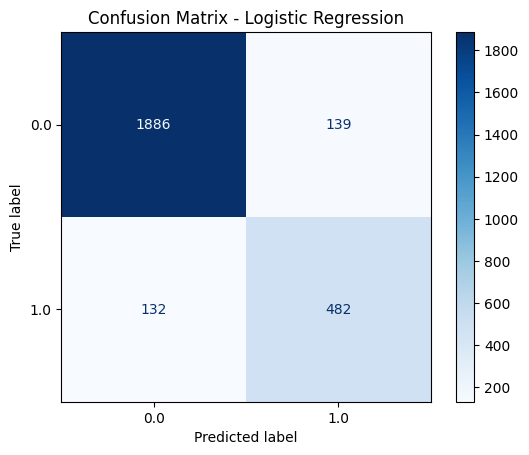

Logistic Regression       |ROC_AUC: 0.8582 
Random Forest             
 [[1946   79]
 [ 180  434]] 
               precision    recall  f1-score   support

         0.0       0.92      0.96      0.94      2025
         1.0       0.85      0.71      0.77       614

    accuracy                           0.90      2639
   macro avg       0.88      0.83      0.85      2639
weighted avg       0.90      0.90      0.90      2639



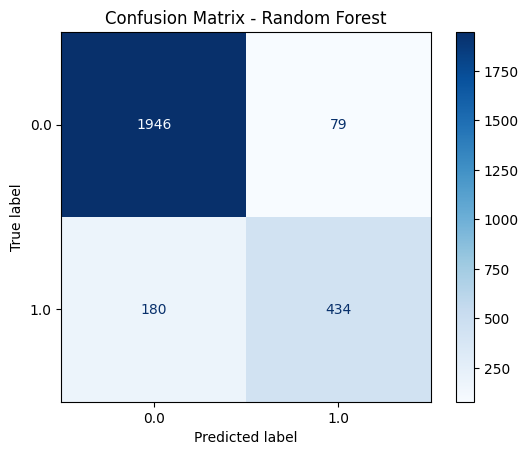

Random Forest             |ROC_AUC: 0.8339 


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[07:19:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




XGBoost                   
 [[1914  111]
 [ 136  478]] 
               precision    recall  f1-score   support

         0.0       0.93      0.95      0.94      2025
         1.0       0.81      0.78      0.79       614

    accuracy                           0.91      2639
   macro avg       0.87      0.86      0.87      2639
weighted avg       0.91      0.91      0.91      2639



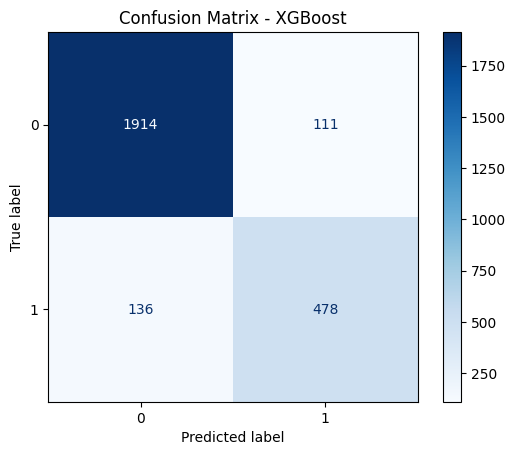

XGBoost                   |ROC_AUC: 0.8618 
Gradient Boosting         
 [[1926   99]
 [ 161  453]] 
               precision    recall  f1-score   support

         0.0       0.92      0.95      0.94      2025
         1.0       0.82      0.74      0.78       614

    accuracy                           0.90      2639
   macro avg       0.87      0.84      0.86      2639
weighted avg       0.90      0.90      0.90      2639



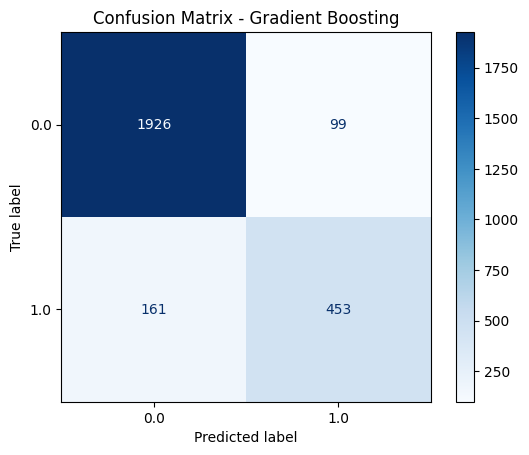

Gradient Boosting         |ROC_AUC: 0.8444 
K-Nearest Neighbors       
 [[1910  115]
 [ 189  425]] 
               precision    recall  f1-score   support

         0.0       0.91      0.94      0.93      2025
         1.0       0.79      0.69      0.74       614

    accuracy                           0.88      2639
   macro avg       0.85      0.82      0.83      2639
weighted avg       0.88      0.88      0.88      2639



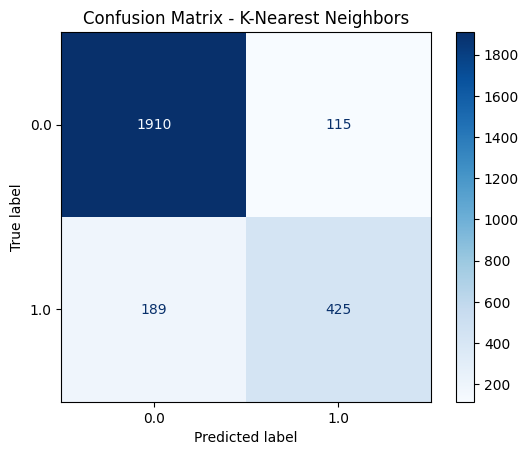

K-Nearest Neighbors       |ROC_AUC: 0.8177 
Decision Tree             
 [[1853  172]
 [ 263  351]] 
               precision    recall  f1-score   support

         0.0       0.88      0.92      0.89      2025
         1.0       0.67      0.57      0.62       614

    accuracy                           0.84      2639
   macro avg       0.77      0.74      0.76      2639
weighted avg       0.83      0.84      0.83      2639



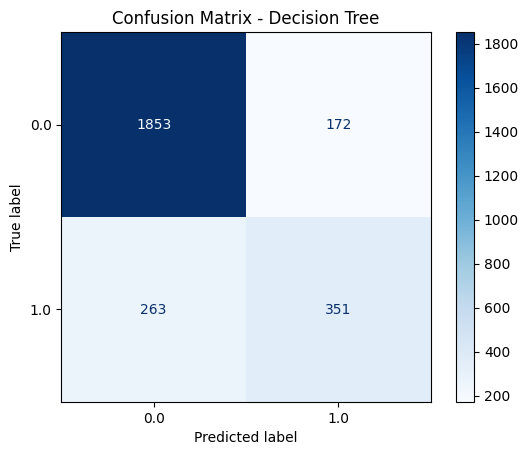

Decision Tree             |ROC_AUC: 0.7434 
Support Vector Machine    
 [[1931   94]
 [ 139  475]] 
               precision    recall  f1-score   support

         0.0       0.93      0.95      0.94      2025
         1.0       0.83      0.77      0.80       614

    accuracy                           0.91      2639
   macro avg       0.88      0.86      0.87      2639
weighted avg       0.91      0.91      0.91      2639



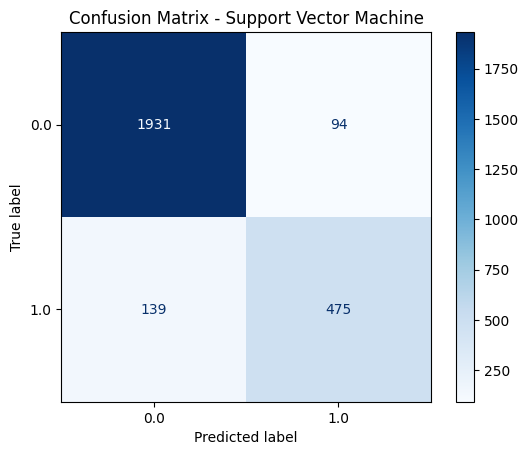

Support Vector Machine    |ROC_AUC: 0.8636 


In [27]:


results_pca = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    roc = roc_auc_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    results_pca[name] = {'Accuracy': accuracy, 'ROC_AUC': roc}

    confusion = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)
    print(f"{name:25s}","\n",confusion_matrix(y_test, y_pred),"\n",classification_rep)
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=model.classes_)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    print(f"{name:25s} |ROC_AUC: {roc:.4f} ")

In [23]:
# RESULTS COMPARISON
model_names = list(models.keys())
acc_no_pca = [results_no_pca[m]['Accuracy'] for m in model_names]
acc_pca = [results_pca[m]['Accuracy'] for m in model_names]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names, y=acc_no_pca,
    name='Without PCA (Original Scaled)',
    marker_color='#2c3e50',
    text=[f"{val:.3f}" for val in acc_no_pca],
    textposition='auto'
))

fig.add_trace(go.Bar(
    x=model_names, y=acc_pca,
    name='With PCA (Reduced Dimensions)',
    marker_color='#e74c3c',
    text=[f"{val:.3f}" for val in acc_pca],
    textposition='auto'
))

fig.update_layout(
    title='Model Accuracy Comparison: Without PCA vs With PCA',
    xaxis_tickfont_size=14,
    yaxis=dict(title='Accuracy Score', titlefont_size=16, tickfont_size=14, range=[0, 1.1]),
    legend=dict(x=0.01, y=1.05, orientation="h"),
    barmode='group',
    bargap=0.15,
    bargroupgap=0.1,
    height=600
)

fig.show()


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[07:14:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




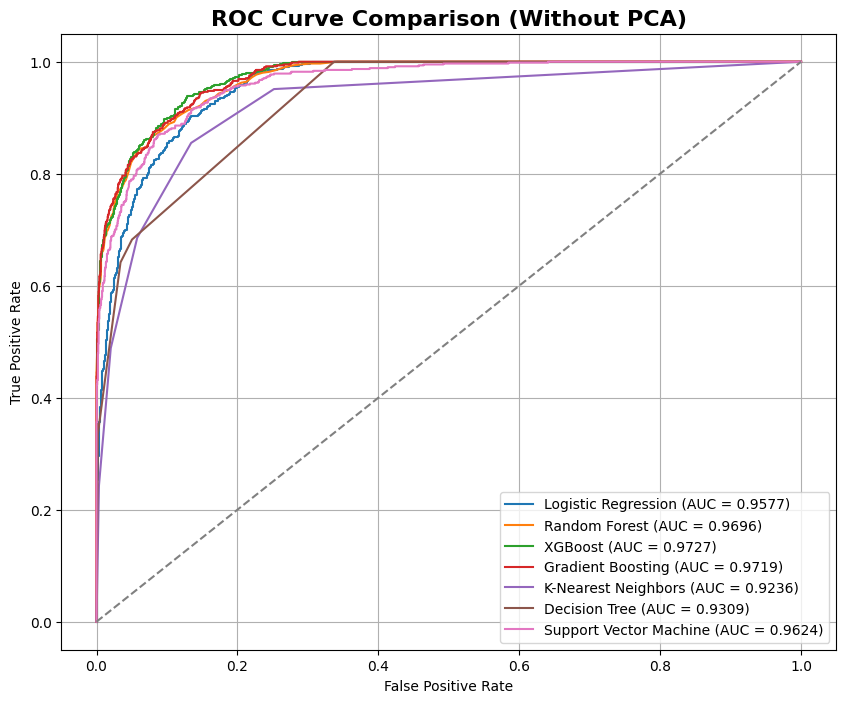

In [24]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Without PCA)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[07:14:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




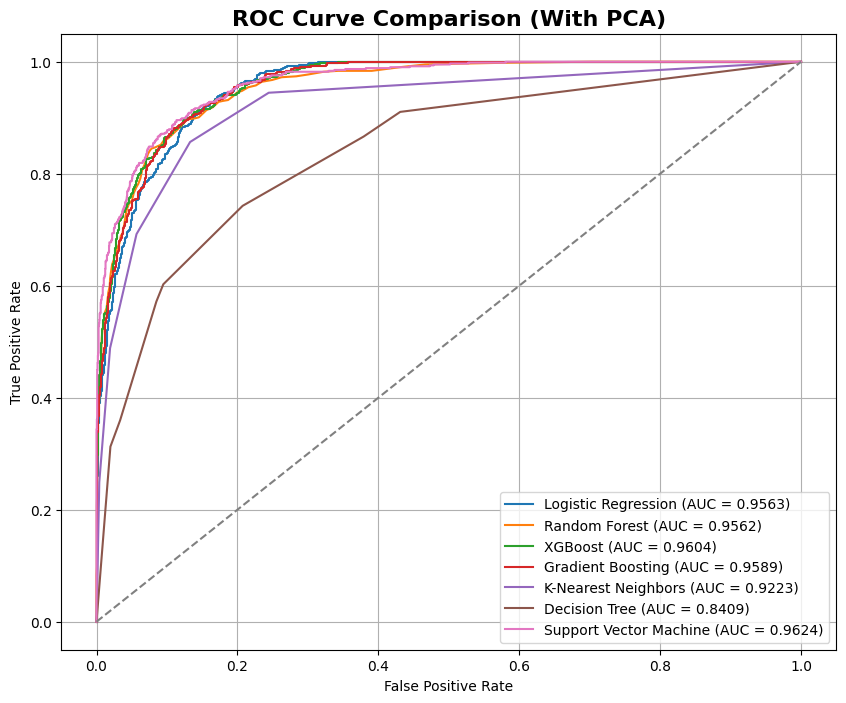

In [25]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_pca)[:, 1]
    else:
        y_probs = model.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (With PCA)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()